In [49]:
from openpiv import tools, pyprocess, validation, filters, scaling

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import io
from PIL import Image
from IPython.display import Image as IPyImage, display
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/PIV/')   

import imageio
import pathlib
import cmcrameri.cm as cm
import pandas as pd
from piv_func import perform_piv

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

# Particle Image Velocimetry
#### Kjersti Stangeland, Spring 2026
**Analyzing**:
* f = 1.4 Hz
* A = 0.2 V
* D = 0.2 m
* H = 0.15 m

Run 1 out of 3

PIV was done between 8.06 m and 8.26 m in the tank. The recordings began 10 seconds after paddle initialization, and had a duration of 20 seconds. As the recordings were taken between probe P2 and P3, I will do the PIV analysis for the first period after 20 seconds (10 seconds after start of recording).

In [50]:
ims = np.linspace(1250, 1339, 90)
frames = {}

for im in ims:
    im_int = int(im)
    img = tools.imread(f'/Users/kjesta/Desktop/LABDATA/PIV/f14a02/bitmap/image_p{im_int}.bmp')
    frames[im_int] = img

In [51]:
T = 1/1.4  # wave period, seconds
fps = 125  # frames per second
dt = 1/fps  # time between frames, seconds
fpp = fps*T  # frames per period
images_needed = int(fpp)

print(f"Frames per period: {fpp:.2f}")
print(f"Time between frames: {dt:.4f} s")
print(f"Total images needed for one period: {images_needed}")
print(f"Frames opened: {len(frames)}")

Frames per period: 89.29
Time between frames: 0.0080 s
Total images needed for one period: 89
Frames opened: 90


In [52]:
timestamps = [i * dt + 10 for i in list(frames.keys())] # timestamps for one period, starting at 10 seconds

In [53]:
# Indices for region of analysis
# Cuts off the top and bottom of the image, 
# and a small part on the left and right to match reference

y_min = 615
y_max = 1725

x_min = 15
x_max = 1190

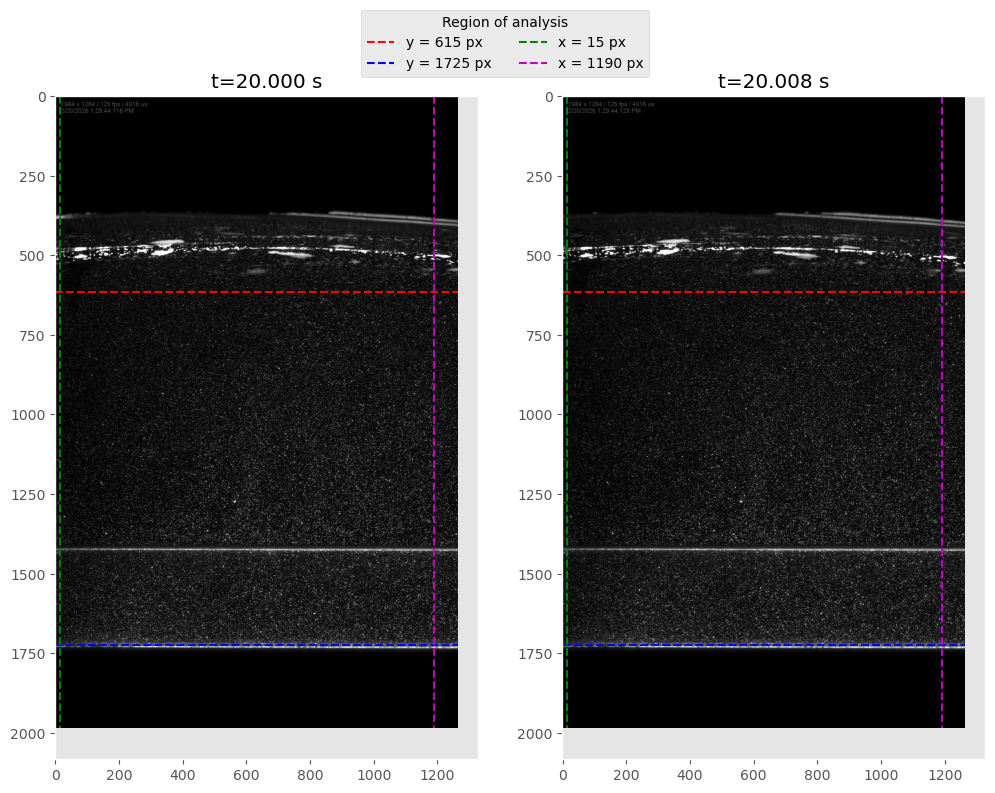

In [54]:
fig, ax =plt.subplots(1,2, figsize=(12,10))
ax[0].imshow(frames[1250], cmap='gray')
ax[0].hlines(y=y_min, xmin=0, xmax=frames[1250].shape[1], colors='r', linestyles='--', label='y = 615 px')
ax[0].hlines(y=y_max, xmin=0, xmax=frames[1250].shape[1], colors='b', linestyles='--', label='y = 1725 px')
ax[0].vlines(x=x_min, ymin=0, ymax=frames[1250].shape[0], colors='g', linestyles='--', label='x = 15 px')
ax[0].vlines(x=x_max, ymin=0, ymax=frames[1250].shape[0], colors='m', linestyles='--', label='x = 1190 px')
ax[0].set_title(f't={timestamps[0]:.3f} s')

ax[1].imshow(frames[1251], cmap='gray')
ax[1].set_title(f't={timestamps[1]:.3f} s')
ax[1].hlines(y=y_min, xmin=0, xmax=frames[1251].shape[1], colors='r', linestyles='--')
ax[1].hlines(y=y_max, xmin=0, xmax=frames[1251].shape[1], colors='b', linestyles='--')
ax[1].vlines(x=x_min, ymin=0, ymax=frames[1251].shape[0], colors='g', linestyles='--')
ax[1].vlines(x=x_max, ymin=0, ymax=frames[1251].shape[0], colors='m', linestyles='--')

ax[0].grid()
ax[1].grid()
fig.legend(title='Region of analysis', loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=2)

In [55]:
plate_top_index = 805

In [56]:
# Zoom in on area of interest
# Ignoring the surface and the bottom of the frame
zoom_frames = {}
for key in frames.keys():
    zoom_frames[key] = frames[key][y_min:y_max, x_min:x_max]

Text(0.5, 0.9, 'Raw, zoomed in, frames')

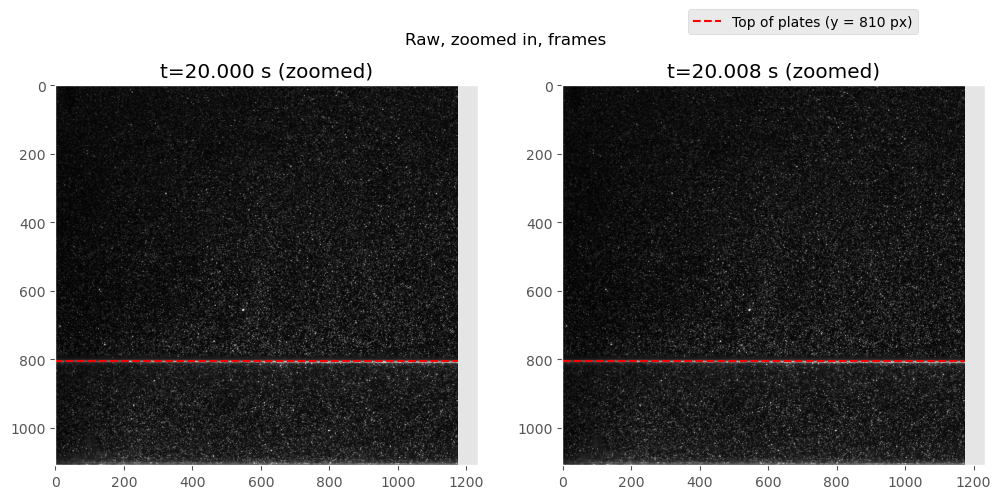

In [57]:
fig, ax =plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(zoom_frames[1250], cmap='gray')
ax[0].set_title(f't={timestamps[0]:.3f} s (zoomed)')
ax[0].hlines(y=plate_top_index, xmin=0, xmax=zoom_frames[1250].shape[1], colors='r', linestyles='--', label='Top of plates (y = 810 px)')

ax[1].imshow(zoom_frames[1251], cmap='gray')
ax[1].set_title(f't={timestamps[1]:.3f} s (zoomed)')
ax[1].hlines(y=plate_top_index, xmin=0, xmax=zoom_frames[1251].shape[1], colors='r', linestyles='--')
ax[0].grid()
ax[1].grid()

fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.95), ncol=2)
fig.suptitle('Raw, zoomed in, frames', y=0.9)

In [58]:
# Load reference image
reference = tools.imread('/Users/kjesta/Desktop/LABDATA/PIV/reference_p29.bmp')

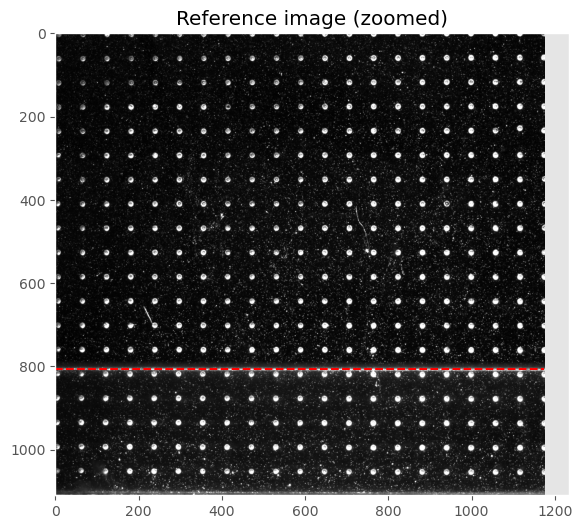

In [59]:
# Zoom in on reference image
reference_zoom = reference[y_min:y_max, x_min:x_max]

fig, ax =plt.subplots(1, figsize=(12,6))
ax.imshow(reference_zoom, cmap='gray')
ax.set_title('Reference image (zoomed)')
ax.hlines(y=plate_top_index, xmin=0, xmax=reference_zoom.shape[1], colors='r', linestyles='--')
ax.grid()

In [60]:
# Distance between pixel 15 and 1190 (in horizontal direction)
x_m = 0.20
# Distance between pixel 615 and 1725 (in vertical direction)
y_m = 0.19

# Calculate pixel to m scaling factors
x_scale = (x_max - x_min) / x_m  # pixel per m
y_scale = (y_max - y_min) / y_m  # pixel per m

print(f"x_scale = {x_scale:.3f} px/m, y_scale = {y_scale:.3f} px/m")
print(f'Percentage difference: {(x_scale-y_scale)/y_scale * 100:.2f}%')

# Average if appropriate
scaling_factor = (x_scale + y_scale) / 2
print(f"Average scaling factor: {scaling_factor:.3f} px/m")

x_scale = 5875.000 px/m, y_scale = 5842.105 px/m
Percentage difference: 0.56%
Average scaling factor: 5858.553 px/m


In [61]:
# Crop frames to region of interest
ims = np.linspace(1250, 1339, 90)
cropped_frames = {}

for im in ims:
    cropped_frames[int(im)] = frames[int(im)][y_min:y_max, x_min:x_max]

In [62]:
# PIV parameters

window_size = 32  # interrogation window size (in pixels)
overlap = 16  # overlap between interrogation windows (in pixels)
search_area_size = 64  # search area size (in pixels)
stepsize = 1

In [63]:
w_bar = []
dw_bar = []
for key in range(1250, 1339, stepsize):
    x, y, u, v = perform_piv(key, stepsize=stepsize, 
                        window_size=window_size, 
                        overlap=overlap, 
                        search_area_size=search_area_size, 
                        scaling_factor=scaling_factor, 
                        cropped_frames=cropped_frames, 
                        timestamps=timestamps)
    
    idx_a = key - 1250
    time_a = timestamps[idx_a]
    idx_b = idx_a + stepsize
    time_b = timestamps[idx_b]

    curl_u = np.gradient(u, axis=0) # du/dz
    curl_w = np.gradient(v, axis=1) # dw/dx
    curl = curl_u - curl_w

    grad_u = np.gradient(u, axis=1) # du/dx
    grad_w = np.gradient(v, axis=0) # dw/dz

    dw_bar.append(np.mean(grad_w[15, :]))

    # Plot the velocity field
    fig, ax = plt.subplots(1, 2, figsize=(14,6))

    ax[0].imshow(cropped_frames[key], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].imshow(cropped_frames[key], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))

    vmin = -0.1
    vmax = 0.1

    umin = 0
    umax = 0.5

    w_ = np.mean(v[15, :])
    w_bar.append(w_)

    im = ax[0].quiver(x, y, u, v, np.sqrt(u**2 + v**2), cmap=cm.imola, scale=1.5)
    im.set_clim(umin, umax)
    cbar = plt.colorbar(im, extend='max', label='Velocity magnitude (m/s)', shrink=0.8)
    ax[0].set_title(f'Velocity field at t={timestamps[idx_a]:.3f} s')
    ax[0].grid()
    ax[0].hlines(y=y[15, :], xmin=x.min(), xmax=x.max(), colors='r', linewidth=0.5, linestyles='--', label=rf'$\bar w$ = {w_bar[-1]:.4f} m/s')
    ax[0].legend()

    im1 = ax[1].quiver(x, y, np.zeros_like(v), v, v, scale=1.5, cmap=cm.vik)
    im1.set_clim(vmin, vmax)
    cbar1 = plt.colorbar(im1, extend='both', label='v component (m/s)', shrink=0.8)
    ax[1].set_title(f'Vertical velocity component at t={timestamps[idx_b]:.3f} s')
    ax[1].grid()
    ax[1].hlines(y=y[15, :], xmin=x.min(), xmax=x.max(), colors='r', linewidth=0.5, linestyles='--', label=rf'$\bar w$ = {w_bar[-1]:.4f} m/s')
    ax[1].legend()

    plt.savefig(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/PIV/figs/f14a02/vel_field_{key}_r1.png', dpi=300)
    plt.close(fig)

    # Plot the vorticity and velocity gradients

    vmin = -0.35
    vmax = 0.35
    vlevs = np.linspace(vmin, vmax, 51)

    umin = -0.35
    umax = 0.35
    ulevs = np.linspace(umin, umax, 51)

    wmin = -0.05
    wmax = 0.05
    wlevs = np.linspace(wmin, wmax, 51)

    fig, ax = plt.subplots(1, 3, figsize=(18,6))
    im = ax[0].contourf(x, y, curl, alpha=0.5, levels=vlevs, cmap=cm.vik, extend='both')
    ax[0].imshow(cropped_frames[key], cmap='gray_r', alpha=0.5,extent=(x.min(), x.max(), y.max(), y.min()))
    cbar = plt.colorbar(im, ax=ax[0], label='Vorticity (1/s)', shrink=0.7)
    ax[0].set_title('Vorticity Field')
    ax[0].grid()

    im = ax[1].contourf(x, y, grad_u, alpha=0.5, cmap=cm.vik, levels=ulevs, extend='both')
    cbar = plt.colorbar(im, ax=ax[1], label=r'$\partial u / \partial x$ (1/s)', shrink=0.7)
    ax[1].set_title('Horizontal Velocity Gradient')
    ax[1].imshow(cropped_frames[key], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].grid()

    im = ax[2].contourf(x, y, grad_w, alpha=0.5, cmap=cm.vik, levels=wlevs, extend='both')
    cbar = plt.colorbar(im, ax=ax[2], label=r'$\partial w / \partial z$ (1/s)', shrink=0.7)
    ax[2].set_title('Vertical Velocity Gradient')
    ax[2].imshow(cropped_frames[key], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[2].grid()
    fig.suptitle(f't1 = {timestamps[idx_a]:.3f} s, t2 = {timestamps[idx_b]:.3f} s', y=0.95)
    plt.tight_layout()  
    plt.savefig(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/PIV/figs/f14a02/curl_grad_{key}_r1.png', dpi=300)
    plt.close(fig)

/Users/kjesta/miniconda3/envs/masters/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kjesta/miniconda3/envs/masters/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Max w_bar: 0.0173 m/s at index 20
Max dw_bar: 0.0091 1/s at index 67
Mean w_bar: -0.0003 m/s
Mean dw_bar: 0.0001 1/s


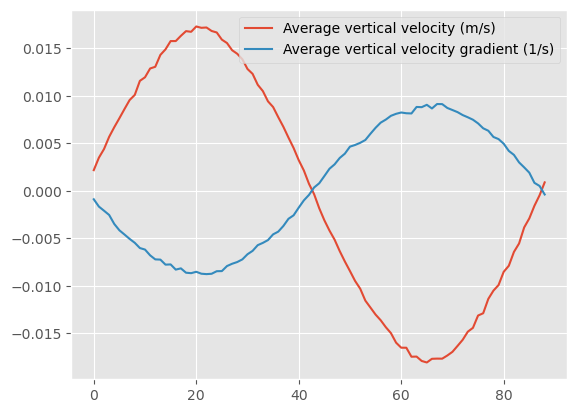

In [71]:
plt.plot(w_bar, label='Average vertical velocity (m/s)')
plt.plot(dw_bar, label='Average vertical velocity gradient (1/s)')
plt.legend()

print(f'Max w_bar: {max(w_bar):.4f} m/s at index {w_bar.index(max(w_bar))}')
print(f'Max dw_bar: {max(dw_bar):.4f} 1/s at index {dw_bar.index(max(dw_bar))}')
print(f'Mean w_bar: {np.mean(w_bar):.4f} m/s')
print(f'Mean dw_bar: {np.mean(dw_bar):.4f} 1/s')